In [1]:
import numpy as np
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
from neurodsp.spectral import compute_spectrum
from neurodsp.filt import filter_signal
import os
from joblib import Parallel, delayed
from tqdm import tqdm
import torch
import scipy

from dynamix.model.forecaster import DynaMixForecaster
from dynamix.utilities.plotting_eval import plot_TS_forecast, plot_3D_attractor
from dynamix.utilities.utilities import load_hf_model

In [8]:
# define file paths
eeg_path = '/oscar/data/sjones/shared/TDBRAIN_preprocessed/preprocessed'
metadata_path = '../data/TDBRAIN_participants_V2.tsv'
subj_list = os.listdir(eeg_path)
print("Number of total subjects:", len(subj_list))

# read data
metadata_df = pd.read_csv(metadata_path, delimiter='\t')

# generate mask to pull out MDD, DISC subjects only
subj_mask = np.isin(metadata_df['participants_ID'].values, subj_list)
discovery_mask = metadata_df['DISC/REP'].values == 'DISCOVERY'
dataset_mask = metadata_df['Dataset'].values == 'MDD-rTMS'
rTMS_mask = ~metadata_df['rTMS PROTOCOL'].isna() # excludes 1 participant

mask = np.logical_and.reduce([subj_mask, discovery_mask, dataset_mask, rTMS_mask])

df = metadata_df[mask].copy() # .copy because plan to add columns later
df['age']  = df['age'].str.replace(',', '.').astype(float) # convert age to float
print("Shape after keeping MDD-rTMS, Discovery rows:", df.shape)

duplicate_ids = df["participants_ID"].value_counts()
duplicate_ids = duplicate_ids[duplicate_ids > 1].index
df = df.drop_duplicates(subset="participants_ID", keep="first")
print("Shape after keeping only first entry for each participant:", df.shape)

# save paths to eeg numpy files for each subject in df
ec_eeg_path, eo_eeg_path, has_ses1 = list(), list(), list()

for subj_id in df['participants_ID'].values:
    subj_path = f'{eeg_path}/{subj_id}/ses-1/eeg'
    if os.path.isdir(subj_path):
        has_ses1.append(True)
        subj_files = os.listdir(subj_path)
        ec_subj_files = list(pathlib.Path(subj_path).glob('*restEC*.npy'))
        eo_subj_files = list(pathlib.Path(subj_path).glob('*restEO*.npy'))
        assert len(ec_subj_files) == len(eo_subj_files) == 1

        ec_eeg_path.append(str(ec_subj_files[0]))
        eo_eeg_path.append(str(eo_subj_files[0]))

    else:
        has_ses1.append(False)
        ec_eeg_path.append('')
        eo_eeg_path.append('')

df['ec_eeg_path'] = ec_eeg_path
df['eo_eeg_path'] = eo_eeg_path
df['has_ses1'] = has_ses1

df = df[df['has_ses1'] == True].reset_index(drop=True)
print("Shape after removing subj with no session 1 data:", df.shape)

def get_eeg_data(subj_data_path):

    channel_filter = ['F7', 'P8', 'T7', 'O2']
    # channel_filter = ['Fp1','Fz', 'F4', 'O1', 'Oz', 'O2',]

    eeg_dict = np.load(subj_data_path, allow_pickle=True)
    channel_labels = eeg_dict['labels']
    sampling_freq = eeg_dict['Fs']

    channel_mask = np.isin(channel_labels, channel_filter)
    eeg_data = eeg_dict['data'][0, channel_mask, :]


    return eeg_data

# extract features in parallel for all subjects
ec_res = Parallel(n_jobs=16)(delayed(get_eeg_data)(ec_path) for ec_path in tqdm(df['ec_eeg_path'].values[:10]))
eo_res = Parallel(n_jobs=16)(delayed(get_eeg_data)(eo_path) for eo_path in tqdm(df['eo_eeg_path'].values[:10]))



Number of total subjects: 1274
Shape after keeping MDD-rTMS, Discovery rows: (131, 111)
Shape after keeping only first entry for each participant: (123, 111)
Shape after removing subj with no session 1 data: (120, 114)



100%|██████████| 10/10 [00:00<00:00, 2733.87it/s]

100%|██████████| 10/10 [00:00<00:00, 13967.05it/s]


In [59]:
subj_idx = 1
fs = 500 

context_eo = eo_res[subj_idx]
context_ec = ec_res[subj_idx]


freqs, context_spectrum_ec = compute_spectrum(context_ec, fs=fs)
_ , context_spectrum_eo = compute_spectrum(context_eo, fs=fs)

freq_min, freq_max = 0, 50
freq_mask = np.logical_and(freqs < freq_max, freqs > freq_min)



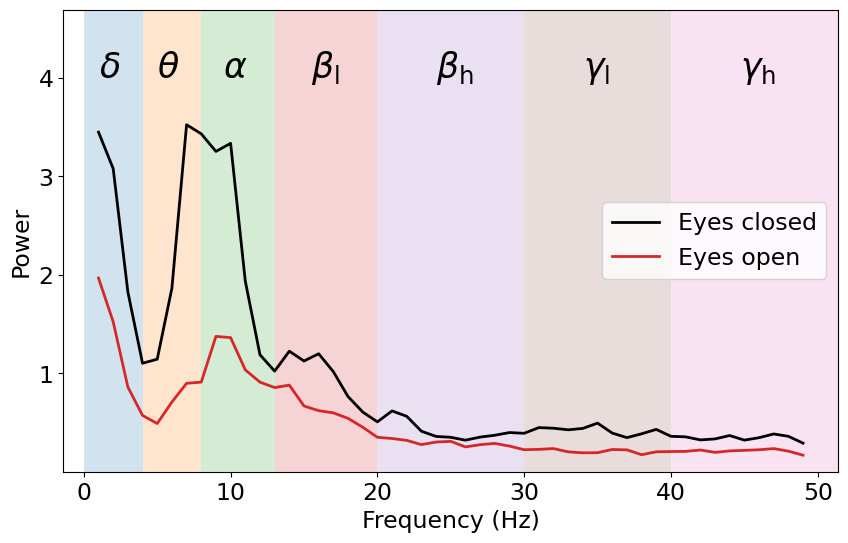

In [91]:
labelsize = 17
ticksize = 17
legendsize = 17

plt.figure(figsize=(10,6))
plt.plot(freqs[freq_mask], context_spectrum_ec[0,freq_mask], color='k', linewidth=2, label='Eyes closed')
plt.plot(freqs[freq_mask], context_spectrum_eo[0,freq_mask], color='C3', linewidth=2, label='Eyes open')

plt.xticks(fontsize=ticksize)
plt.yticks(fontsize=ticksize)
plt.xlabel('Frequency (Hz)', fontsize=labelsize)
plt.ylabel('Power', fontsize=labelsize)

ymin, ymax = plt.ylim()
xmin, xmax = plt.xlim()

bands  = {'delta': ((0, 4),'$\\delta$'), 'theta': ((4, 8),'$\\theta$'), 'alpha': ((8, 13),'$\\alpha$'), 'low_beta': ((13, 20),'$\\beta_{\\rm l}$'),
          'high_beta': ((20, 30),'$\\beta_{\\rm h}$'), 'low_gamma': ((30, 40),'$\\gamma_{\\rm l}$'), 'high_gamma': ((40, xmax),'$\\gamma_{\\rm h}$')}

for band_name, (band_range, symbol) in bands.items():
    plt.fill_between(band_range, -10, 10, alpha=0.2)
    plt.text(np.mean(band_range)- 1, 4, symbol, fontsize=25)

plt.ylim(ymin, ymax+ 1)
plt.xlim(xmin, xmax)
plt.legend(fontsize=legendsize)
plt.savefig('../figures/power_spectrum_schematic.svg')